In [1]:
!pip install datasets huggingface_hub scipy -q

In [2]:
from datasets import load_dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.linalg import norm
import re
import warnings
warnings.filterwarnings('ignore')

ds = load_dataset('aida-ugent/JobHop')

df_train = ds['train'].to_pandas()
df_val   = ds['validation'].to_pandas()
df_test  = ds['test'].to_pandas()

df = pd.concat([df_train, df_val, df_test], ignore_index=True)

print(f'{len(df):,} rows\n')
print(f'Columns: {list(df.columns)}')
print()
print(df.head(3).to_string())

README.md: 0.00B [00:00, ?B/s]

JobHop_train.csv:   0%|          | 0.00/380M [00:00<?, ?B/s]

JobHop_val.csv:   0%|          | 0.00/47.5M [00:00<?, ?B/s]

JobHop_test.csv:   0%|          | 0.00/47.7M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1341832 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/167945 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/167924 [00:00<?, ? examples/s]

1,677,701 rows

Columns: ['person_id', 'matched_label', 'matched_description', 'matched_code', 'start_date', 'end_date', 'university_studies']

   person_id              matched_label                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              matched_description matched_code start_date end_date  university_studies
0          0           resource manager                                                                   

In [3]:
print(f'Rows: {len(df):,}   Columns: {df.shape[1]}\n\n')

#columns
print(f'{df.dtypes}\n\n')

#check for missing values
print(df.isnull().sum())

print(df.head(10))

Rows: 1,677,701   Columns: 7


person_id               int64
matched_label          object
matched_description    object
matched_code           object
start_date             object
end_date               object
university_studies       bool
dtype: object


person_id                   0
matched_label               0
matched_description         0
matched_code            13876
start_date             192898
end_date               372815
university_studies          0
dtype: int64
   person_id                              matched_label  \
0          0                           resource manager   
1          0                  health and safety officer   
2          0                       integration engineer   
3          0                          programme manager   
4          0    product development engineering drafter   
5          0                               move manager   
6          0  customer contact centre information clerk   
7          0                      ICT help desk 

# Change quarter to year and remove null values

In [4]:
def quarter_to_year(q_str):

    if pd.isna(q_str):
        return np.nan
    match = re.search(r'(\d{4})', str(q_str))
    return int(match.group(1)) if match else np.nan


#clean data
before = len(df)

#remove rows with unknown in their matched_label and matched_description column
df = df[df['matched_label'].str.lower() != 'unknown'].copy()
print(f'Rows dropped: {before - len(df):,}')

df['year'] = df['start_date'].apply(quarter_to_year)

#drop rows with missing start date
before = len(df)
df = df.dropna(subset=['year'])
df['year'] = df['year'].astype(int)
print(f'Rows dropped {before - len(df):,} ')

df = df.sort_values(['person_id', 'year'])

print(f'\nClean dataset: {len(df):,} rows')
print(f'Users: {df["person_id"].nunique():,}')
print(f'Unique jobs: {df["matched_label"].nunique():,}')
print(f'Year range: {df["year"].min()} \u2013 {df["year"].max()}')

Rows dropped: 271,837
Rows dropped 190,289 

Clean dataset: 1,215,575 rows
Users: 314,875
Unique jobs: 2,959
Year range: 1955 – 2024


# Preprocessing: 27-Sector ESCO Classifier (2-Pass: Title + Description Fallback)

This cell implements a refined 27-sector taxonomy (ported from validated R pipeline) with:
- **Pass 1**: job title classification using 800+ regex patterns
- **Pass 2**: description fallback for unclassified titles
- **Auto-removal** of remaining `Other & Unclassified` rows before modelling

This reduces noise in the transition matrix and improves prediction accuracy.

In [5]:
import pandas as pd
import numpy as np
import re

def esco_title(title, description=""):
    """
    Two-pass ESCO sector classifier.
    Pass 1: job title
    Pass 2: description fallback (if provided)
    Returns sector string or 'Other & Unclassified'.
    """
    def _classify(t):
        # 1. Software & IT Development
        if re.search(
            r'software engineer|software developer|software architect|' +
            r'web developer|web designer|front.?end|back.?end|full.?stack|' +
            r'mobile developer|android developer|ios developer|app developer|' +
            r'devops engineer|devops specialist|site reliability|cloud engineer|platform engineer|' +
            r'embedded engineer|firmware engineer|game developer|' +
            r'ui developer|ux engineer|wordpress developer|' +
            r'php developer|java developer|python developer|ruby developer|' +
            r'\\.net developer|golang developer|kotlin developer|swift developer|' +
            r'software tester|qa engineer|quality assurance engineer|test engineer|' +
            r'automation engineer|release engineer|build engineer|' +
            r'integration engineer|api developer|backend developer|frontend developer|' +
            r'systems developer|application developer|application engineer|' +
            r'solutions developer|technical developer|programmer|coder|' +
            r'software quality|software analyst|software specialist|software consultant|' +
            r'software support|software lead|software manager|software officer|' +
            r'react developer|node developer|cloud developer|saas developer|' +
            r'platform developer|api engineer|test automation|performance engineer|' +
            r'security developer|devsecops developer|mobile engineer', t):
            return 'Software & IT Development'

        # 2. Data Science & Analytics
        if re.search(
            r'data scientist|data analyst|data engineer|' +
            r'machine learning engineer|ml engineer|ai engineer|' +
            r'deep learning|nlp engineer|computer vision engineer|' +
            r'business intelligence analyst|bi analyst|bi developer|bi engineer|' +
            r'analytics engineer|quantitative analyst|statistician|' +
            r'data architect|big data engineer|data warehouse engineer|etl developer|etl engineer|' +
            r'research scientist|data science manager|' +
            r'data manager|data specialist|data coordinator|data officer|data director|' +
            r'database analyst|reporting analyst|insight analyst|insights manager|' +
            r'information analyst|analytics manager|analytics director|analytics lead|' +
            r'data quality analyst|master data|data governance|data modelling|' +
            r'performance analyst|revenue analyst|pricing analyst|' +
            r'forecasting analyst|demand analyst|planning analyst|' +
            r'tableau developer|power bi developer|qlik developer|looker developer|' +
            r'metrics analyst|kpi analyst|intelligence analyst', t):
            return 'Data Science & Analytics'

        # 3. Cybersecurity & Compliance
        if re.search(
            r'security analyst|security engineer|cybersecurity analyst|cybersecurity engineer|' +
            r'information security officer|infosec analyst|penetration tester|' +
            r'ethical hacker|soc analyst|security architect|security operations|' +
            r'network security engineer|cloud security engineer|security consultant|' +
            r'vulnerability analyst|incident response analyst|digital forensics|' +
            r'security officer|data protection officer|gdpr specialist|' +
            r'cyber analyst|cyber engineer|cyber specialist|cyber manager|' +
            r'security specialist|security manager|security director|security lead|' +
            r'security administrator|security technician|security advisor|' +
            r'risk and compliance analyst|it compliance analyst|' +
            r'identity access management|iam engineer|zero trust specialist|' +
            r'threat intelligence|malware analyst|application security|cryptography engineer', t):
            return 'Cybersecurity & Compliance'

        # 4. IT Infrastructure & Networks
        if re.search(
            r'network engineer|network administrator|network architect|network manager|' +
            r'systems administrator|sysadmin|linux administrator|linux engineer|' +
            r'windows administrator|windows engineer|infrastructure engineer|' +
            r'cloud architect|aws engineer|azure engineer|gcp engineer|' +
            r'database administrator|\\bdba\\b|storage engineer|storage administrator|' +
            r'it support engineer|helpdesk engineer|help desk analyst|service desk analyst|' +
            r'ict support engineer|desktop support engineer|' +
            r'technical support engineer|it technician|it administrator|' +
            r'telecommunications engineer|telecom engineer|network operations|' +
            r'voip engineer|unified communications|rf engineer|' +
            r'network technician|network specialist|infrastructure manager|' +
            r'server engineer|server administrator|virtualisation engineer|' +
            r'cloud administrator|cloud operations|' +
            r'field engineer|field technician|field support engineer|' +
            r'ict specialist|ict technician|ict engineer|ict manager|ict coordinator|' +
            r'broadband engineer|fibre engineer|telecoms engineer|' +
            r'hardware engineer|hardware technician|data centre engineer|' +
            r'it operations manager|noc engineer|monitoring engineer', t):
            return 'IT Infrastructure & Networks'

        # 5. ICT Management & Consulting
        if re.search(
            r'ict manager|ict director|ict consultant|information technology manager|' +
            r'it consultant|technology consultant|it manager|it director|' +
            r'technology manager|technology director|\\bcto\\b|chief technology officer|' +
            r'it project manager|scrum master|agile coach|agile consultant|' +
            r'product owner|technical lead|solutions architect|enterprise architect|' +
            r'digital transformation manager|digital manager|digital director|' +
            r'it governance manager|it strategist|it business analyst|' +
            r'product manager|product director|product lead|product analyst|' +
            r'technical manager|technical director|technical consultant|technical advisor|' +
            r'chief digital officer|chief information officer|\\bcio\\b|' +
            r'it coordinator|information manager|information officer|knowledge manager|' +
            r'digital officer|digital lead|digital consultant|digital analyst|' +
            r'systems analyst|technology analyst|technology officer|technology specialist', t):
            return 'ICT Management & Consulting'

        # 6. Senior Management & C-Suite
        if re.search(
            r'chief executive officer|\\bceo\\b|chief operating officer|\\bcoo\\b|' +
            r'chief financial officer|\\bcfo\\b|chief marketing officer|\\bcmo\\b|' +
            r'chief human resources officer|\\bchro\\b|managing director|' +
            r'country manager|regional director|divisional director|' +
            r'vice president|executive vice president|executive director|\\bpresident\\b|' +
            r'global director|global manager|global head|group director|group managing|' +
            r'senior director|senior vice president|\\bsvp\\b|\\bevp\\b|' +
            r'chief officer|chief director|chief of staff|head of department|' +
            r'general manager|chief commercial officer|chief revenue officer|' +
            r'chief product officer|chief people officer|chief strategy officer', t):
            return 'Senior Management & C-Suite'

        # 7. Project & Programme Management
        if re.search(
            r'project manager|programme manager|program manager|' +
            r'project coordinator|project lead|project director|' +
            r'pmo manager|pmo analyst|pmo director|portfolio manager|' +
            r'delivery manager|implementation manager|' +
            r'change manager|transformation manager|change lead|' +
            r'project officer|project analyst|project administrator|' +
            r'project planner|project scheduler|project engineer|project specialist|' +
            r'programme coordinator|programme lead|programme director|programme officer|' +
            r'program coordinator|program lead|program director|program officer|' +
            r'planning manager|planning coordinator|planning specialist|' +
            r'portfolio coordinator|portfolio analyst|portfolio director|' +
            r'project support|project assistant|program support|program analyst', t):
            return 'Project & Programme Management'

        # 8. Operations & General Management
        if re.search(
            r'operations manager|operations director|operations lead|' +
            r'branch manager|area manager|regional manager|territory manager|' +
            r'site manager|facilities manager|building manager|' +
            r'service manager|resource manager|centre manager|center manager|' +
            r'team leader|team manager|supervisor|line manager|' +
            r'head of operations|business operations manager|' +
            r'operations officer|operations analyst|operations specialist|operations coordinator|' +
            r'business manager|office manager|department manager|unit manager|' +
            r'production manager|plant manager|factory manager|manufacturing manager|' +
            r'floor manager|shift manager|duty manager|group manager|' +
            r'process analyst|business process analyst|process improvement|' +
            r'management consultant|business consultant|strategy consultant|' +
            r'strategy manager|strategy analyst|strategy director|strategy lead|' +
            r'commercial manager|commercial director|commercial analyst|commercial lead|' +
            r'general manager|business improvement|operational excellence', t):
            return 'Operations & General Management'

        # 9. Human Resources & Recruitment
        if re.search(
            r'human resources manager|hr manager|hr director|hr business partner|\\bhrbp\\b|' +
            r'hr generalist|hr specialist|people manager|people director|people partner|' +
            r'talent acquisition manager|recruiter|recruitment manager|headhunter|' +
            r'talent manager|learning and development|l.d specialist|l.d manager|' +
            r'training manager|training specialist|training coordinator|training officer|' +
            r'organisational development|org development|od consultant|' +
            r'compensation and benefits|benefits manager|payroll manager|payroll specialist|' +
            r'workforce planning|workforce analyst|' +
            r'hr officer|hr coordinator|hr administrator|hr assistant|hr advisor|' +
            r'hr analyst|hr consultant|hr lead|hr executive|' +
            r'people operations|people analytics|people officer|' +
            r'talent partner|talent director|talent officer|talent specialist|' +
            r'employee relations manager|labour relations|' +
            r'diversity and inclusion|equity and inclusion|dei manager|' +
            r'wellbeing manager|engagement manager|culture manager|' +
            r'staffing manager|staffing coordinator|staffing specialist|resourcing manager', t):
            return 'Human Resources & Recruitment'

        # 10. Sales & Business Development
        if re.search(
            r'sales manager|sales director|sales executive|sales leader|' +
            r'sales representative|sales consultant|sales engineer|' +
            r'account executive|account manager|account director|account lead|' +
            r'business development manager|business development director|\\bbdm\\b|\\bbde\\b|' +
            r'inside sales|field sales|telesales|outbound sales|' +
            r'revenue manager|revenue director|revenue operations|' +
            r'key account manager|national account manager|channel manager|channel sales|' +
            r'sales officer|sales coordinator|sales analyst|sales specialist|' +
            r'sales associate|sales agent|sales advisor|sales administrator|' +
            r'account officer|account specialist|account coordinator|' +
            r'pre.?sales consultant|pre.?sales engineer|solution sales|' +
            r'commercial sales|retail sales|direct sales|b2b sales|b2c sales|' +
            r'partnership manager|alliances manager|vendor manager|' +
            r'client acquisition|new business manager|lead generation manager|' +
            r'sales operations|crm manager|sales enablement|sales trainer', t):
            return 'Sales & Business Development'

        # 11. Marketing & Communications
        if re.search(
            r'marketing manager|marketing director|marketing lead|marketing executive|' +
            r'digital marketing manager|seo specialist|sem specialist|ppc specialist|' +
            r'social media manager|content manager|content strategist|content director|' +
            r'brand manager|brand director|brand strategist|brand specialist|' +
            r'communications manager|communications director|communications lead|' +
            r'public relations manager|pr manager|media relations manager|' +
            r'copywriter|creative director|campaign manager|campaign specialist|' +
            r'growth manager|demand generation manager|email marketing manager|' +
            r'market research analyst|product marketing manager|' +
            r'marketing officer|marketing coordinator|marketing assistant|' +
            r'marketing specialist|marketing consultant|marketing analyst|marketing strategist|' +
            r'content creator|content writer|content producer|content analyst|' +
            r'media manager|media officer|media coordinator|media analyst|' +
            r'press officer|press manager|public affairs manager|' +
            r'internal communications|corporate communications manager|' +
            r'advertising manager|media planner|media buyer|programmatic manager|' +
            r'community manager|influencer manager|crm analyst|marketing automation', t):
            return 'Marketing & Communications'

        # 12. Customer Service & Support
        if re.search(
            r'customer service manager|customer support manager|customer success manager|' +
            r'customer experience manager|\\bcx manager\\b|customer relations manager|' +
            r'client service manager|client relations manager|client success manager|' +
            r'call centre manager|contact centre manager|customer contact manager|' +
            r'customer care manager|customer care agent|complaints manager|' +
            r'customer advisor|service advisor|customer agent|customer representative|' +
            r'customer officer|customer specialist|customer coordinator|' +
            r'client manager|client coordinator|client advisor|client specialist|' +
            r'customer operations manager|service operations manager|' +
            r'call center agent|call agent|contact agent|contact specialist|' +
            r'support agent|support specialist|support coordinator|support manager|' +
            r'customer liaison|client liaison|service representative|' +
            r'after.?sales manager|customer retention|account support|' +
            r'customer clerk|service clerk|customer assistant|helpdesk agent|' +
            r'customer onboarding|customer enablement|customer engagement', t):
            return 'Customer Service & Support'

        # 13. Finance & Accounting
        if re.search(
            r'\\baccountant\\b|accounting manager|financial analyst|finance manager|' +
            r'finance director|financial controller|\\bcontroller\\b|group accountant|' +
            r'internal auditor|external auditor|audit manager|' +
            r'tax advisor|tax manager|tax consultant|tax analyst|tax specialist|' +
            r'management accountant|cost accountant|chartered accountant|' +
            r'credit analyst|credit manager|treasury analyst|treasury manager|' +
            r'accounts payable|accounts receivable|\\bbookkeeper\\b|' +
            r'payroll manager|payroll analyst|financial reporting manager|' +
            r'finance officer|finance analyst|finance coordinator|finance specialist|' +
            r'finance consultant|finance assistant|finance lead|finance administrator|' +
            r'accounting director|accounting officer|' +
            r'financial manager|financial officer|financial coordinator|financial specialist|' +
            r'financial consultant|financial planner|' +
            r'\\bcpa\\b|\\bcfa\\b|\\bacca\\b|\\bcima\\b|aca qualified|' +
            r'audit officer|audit analyst|audit specialist|audit coordinator|' +
            r'budget analyst|budget manager|budgeting specialist|' +
            r'cash manager|\\bcashier\\b|finance clerk|payroll clerk|payroll officer|' +
            r'accounts manager|accounts clerk|accounts assistant|' +
            r'fp.a analyst|fp.a manager|group finance|corporate finance manager', t):
            return 'Finance & Accounting'

        # 14. Banking, Finance & Insurance
        if re.search(
            r'investment banker|investment analyst|fund manager|fund analyst|' +
            r'portfolio manager|wealth manager|' +
            r'stockbroker|equity trader|fixed income analyst|derivatives analyst|' +
            r'risk analyst|risk manager|risk officer|risk specialist|risk director|' +
            r'compliance analyst|compliance manager|compliance officer|' +
            r'retail banker|branch banker|mortgage advisor|mortgage broker|' +
            r'loan officer|\\bunderwriter\\b|\\bactuary\\b|\\binsurance\\b|' +
            r'investment manager|investment director|investment officer|' +
            r'asset manager|private equity analyst|hedge fund analyst|venture capital analyst|' +
            r'banking manager|banking analyst|banking officer|banking specialist|' +
            r'credit officer|credit specialist|credit director|' +
            r'mortgage manager|mortgage specialist|mortgage underwriter|' +
            r'insurance officer|insurance broker|claims manager|claims analyst|claims officer|' +
            r'financial risk manager|market risk analyst|credit risk analyst|operational risk|' +
            r'quantitative analyst|capital markets analyst|securities analyst|' +
            r'banking associate|banking director|financial services manager|' +
            r'actuarial analyst|reinsurance analyst|bancassurance manager|' +
            r'relationship manager|private banker|treasury dealer|fx trader', t):
            return 'Banking, Finance & Insurance'

        # 15. Legal & Compliance
        if re.search(
            r'\\blawyer\\b|solicitor|barrister|attorney|legal counsel|in.?house counsel|' +
            r'legal advisor|legal manager|general counsel|senior counsel|' +
            r'paralegal|legal assistant|legal executive|legal associate|' +
            r'contract manager|contracts manager|contract specialist|contract analyst|' +
            r'patent attorney|intellectual property lawyer|' +
            r'legal secretary|court clerk|\\bmagistrate\\b|\\bnotary\\b|' +
            r'legal officer|legal specialist|legal coordinator|legal director|' +
            r'legal analyst|legal consultant|legal lead|legal partner|' +
            r'corporate counsel|employment lawyer|commercial lawyer|' +
            r'compliance manager|compliance director|compliance specialist|' +
            r'regulatory affairs manager|regulatory manager|regulatory officer|' +
            r'regulatory specialist|regulatory analyst|regulatory consultant|' +
            r'governance manager|governance officer|governance specialist|' +
            r'legal researcher|trainee solicitor|conveyancer|' +
            r'litigation manager|arbitration specialist|mediator|data privacy lawyer', t):
            return 'Legal & Compliance'

        # 16. Engineering & Manufacturing
        if re.search(
            r'mechanical engineer|civil engineer|structural engineer|' +
            r'electrical engineer|electronic engineer|power engineer|' +
            r'chemical engineer|process engineer|process technologist|' +
            r'manufacturing engineer|production engineer|' +
            r'quality engineer|design engineer|product engineer|' +
            r'aerospace engineer|automotive engineer|systems engineer|' +
            r'materials engineer|industrial engineer|energy engineer|petroleum engineer|' +
            r'mining engineer|geological engineer|\\bsurveyor\\b|' +
            r'cad engineer|cad technician|engineering technician|draughtsman|' +
            r'controls engineer|instrumentation engineer|plc engineer|' +
            r'commissioning engineer|validation engineer|qualification engineer|' +
            r'reliability engineer|maintenance engineer|maintenance technician|' +
            r'plant engineer|facilities engineer|project engineer|' +
            r'nuclear engineer|metallurgist|polymer engineer|' +
            r'r.d engineer|product development engineer|innovation engineer|' +
            r'manufacturing technician|production technician|quality technician|' +
            r'quality inspector|quality controller|quality manager|quality director|' +
            r'machine operator|plant operator|process operator|' +
            r'toolmaker|machinist|\\bfitter\\b|\\bfabricator\\b|\\bassembler\\b|' +
            r'production supervisor|manufacturing supervisor|production director|' +
            r'engineering manager|engineering director|chief engineer|lead engineer|principal engineer', t):
            return 'Engineering & Manufacturing'

        # 17. Construction & Architecture
        if re.search(
            r'construction manager|site engineer|quantity surveyor|' +
            r'building manager|construction director|construction engineer|' +
            r'\\barchitect\\b|urban planner|interior designer|interior architect|' +
            r'\\belectrician\\b|\\bplumber\\b|\\bcarpenter\\b|\\bjoiner\\b|' +
            r'bricklayer|painter|decorator|plasterer|' +
            r'\\broofer\\b|\\btiler\\b|glazier|locksmith|' +
            r'hvac engineer|hvac technician|heating engineer|building services engineer|' +
            r'construction coordinator|construction supervisor|construction foreman|' +
            r'site manager|site supervisor|site coordinator|site foreman|' +
            r'building engineer|building surveyor|building inspector|' +
            r'structural architect|landscape architect|landscape designer|' +
            r'civil technician|construction technician|' +
            r'planning engineer|planning manager|planning officer|' +
            r'property developer|real estate developer|development manager|' +
            r'\\bestimator\\b|cost estimator|cost manager|cost planner|' +
            r'scaffolder|groundworker|\\blabourer\\b|construction worker|' +
            r'drainage engineer|utilities engineer|' +
            r'fit.?out manager|refurbishment manager|renovation manager|' +
            r'property manager|property specialist|estate manager|' +
            r'building control officer|structural technician|architectural technician', t):
            return 'Construction & Architecture'

        # 18. Healthcare - Clinical
        if re.search(
            r'\\bdoctor\\b|general practitioner|physician|surgeon|specialist|' +
            r'anaesthetist|radiologist|pathologist|consultant physician|' +
            r'psychiatrist|paediatrician|cardiologist|' +
            r'neurologist|oncologist|dermatologist|' +
            r'dentist|dental surgeon|orthodontist|oral surgeon|' +
            r'ophthalmologist|optometrist|pharmacist|dispensing pharmacist|' +
            r'medical officer|medical manager|medical director|' +
            r'medical consultant|medical specialist|clinical specialist|' +
            r'clinical officer|clinical manager|clinical director|clinical lead|' +
            r'clinical pharmacist|pharmacy manager|pharmacy director|' +
            r'hospital manager|hospital administrator|hospital director|' +
            r'dental therapist|dental hygienist|dental nurse|dental technician|' +
            r'orthopedic surgeon|orthopaedic surgeon|rheumatologist|endocrinologist|' +
            r'gastroenterologist|urologist|gynaecologist|gynecologist|' +
            r'obstetrician|neonatologist|geriatrician|' +
            r'ent specialist|ent surgeon|plastic surgeon|' +
            r'ophthalmic surgeon|dispensing optician|' +
            r'gp registrar|foundation doctor|junior doctor|house officer|' +
            r'sports medicine|occupational physician|forensic physician', t):
            return 'Healthcare - Clinical'

        # 19. Healthcare - Nursing & Allied
        if re.search(
            r'registered nurse|staff nurse|senior nurse|charge nurse|ward nurse|' +
            r'theatre nurse|scrub nurse|recovery nurse|community nurse|' +
            r'mental health nurse|learning disability nurse|district nurse|' +
            r'neonatal nurse|paediatric nurse|oncology nurse|palliative nurse|' +
            r'nursing manager|nursing director|nursing coordinator|nursing officer|' +
            r'nursing assistant|healthcare assistant|\\bhca\\b|\\bhcsw\\b|ward assistant|' +
            r'midwife|midwifery manager|community midwife|' +
            r'paramedic|ambulance technician|emergency medical technician|' +
            r'physiotherapist|physiotherapy manager|' +
            r'occupational therapist|occupational therapy manager|' +
            r'speech therapist|speech and language therapist|' +
            r'radiographer|diagnostic radiographer|therapeutic radiographer|sonographer|' +
            r'dietitian|nutritionist|' +
            r'medical laboratory scientist|biomedical scientist|lab technician|' +
            r'care worker|care assistant|support worker|personal care assistant|' +
            r'health visitor|school nurse|practice nurse|nurse practitioner|' +
            r'allied health professional|healthcare professional|health practitioner|' +
            r'pharmacy technician|dispensary technician|dispensary assistant|' +
            r'medical technician|healthcare technician|clinical technician|' +
            r'care coordinator|care manager|care officer|care home manager|' +
            r'domiciliary care manager|phlebotomist|dialysis technician|' +
            r'patient care coordinator|patient advocate|health educator', t):
            return 'Healthcare - Nursing & Allied'

        # 20. Social Work & Community Services
        if re.search(
            r'social worker|social care manager|social care officer|social care coordinator|' +
            r'community development worker|community support worker|' +
            r'probation officer|youth worker|youth justice|family support worker|' +
            r'case manager|welfare officer|housing officer|housing manager|' +
            r'counsellor|psychotherapist|\\btherapist\\b|counselling manager|' +
            r'mental health support worker|substance misuse worker|' +
            r'disability support worker|rehabilitation specialist|\\bcarer\\b|' +
            r'children.s services|adult services manager|adult services coordinator|' +
            r'community development manager|community engagement manager|' +
            r'community officer|community coordinator|' +
            r'housing coordinator|housing advisor|housing support|tenancy manager|' +
            r'outreach worker|outreach coordinator|outreach manager|' +
            r'family practitioner|family therapist|family coordinator|' +
            r'child protection officer|safeguarding officer|' +
            r'foster care coordinator|adoption worker|' +
            r'psychological therapist|mental health counsellor|bereavement counsellor|' +
            r'addiction counsellor|drug and alcohol worker|' +
            r'learning disability specialist|autism specialist|' +
            r'crisis intervention worker|refuge worker|advocacy worker', t):
            return 'Social Work & Community Services'

        # 21. Education - Teaching
        if re.search(
            r'\\bteacher\\b|head teacher|deputy head teacher|assistant head teacher|' +
            r'primary teacher|secondary teacher|subject teacher|class teacher|form teacher|' +
            r'special needs teacher|sen teacher|learning support teacher|' +
            r'teaching assistant|classroom assistant|learning support assistant|' +
            r'language teacher|esl teacher|tefl teacher|english language teacher|' +
            r'maths teacher|science teacher|physics teacher|chemistry teacher|' +
            r'history teacher|geography teacher|art teacher|music teacher|pe teacher|' +
            r'early years teacher|nursery teacher|eyfs teacher|' +
            r'further education lecturer|adult education teacher|vocational trainer|' +
            r'corporate trainer|training facilitator|' +
            r'e.?learning developer|instructional designer|curriculum developer|' +
            r'education manager|education director|education officer|' +
            r'school administrator|school manager|school coordinator|' +
            r'school counsellor|educational psychologist|' +
            r'nursery manager|nursery assistant|childcare manager|' +
            r'playgroup leader|after.?school coordinator|' +
            r'driving instructor|flight instructor|sports coach|swim teacher|' +
            r'academic coordinator|academic advisor|academic director|' +
            r'university tutor|college lecturer|' +
            r'\\bprofessor\\b|associate professor|\\blecturer\\b|\\breader\\b', t):
            return 'Education - Teaching'

        # 22. Research & Academia
        if re.search(
            r'\\bresearcher\\b|research fellow|postdoctoral researcher|postdoc|' +
            r'academic researcher|\\bscholar\\b|research scientist|' +
            r'laboratory manager|lab manager|laboratory director|' +
            r'research manager|research director|research lead|' +
            r'principal investigator|senior researcher|chief scientist|lead scientist|' +
            r'clinical researcher|clinical research associate|epidemiologist|' +
            r'biologist|molecular biologist|biochemist|microbiologist|immunologist|virologist|' +
            r'chemist|analytical chemist|physicist|materials scientist|' +
            r'research officer|research analyst|research coordinator|' +
            r'research assistant|research associate|research consultant|' +
            r'lab analyst|laboratory analyst|laboratory technician|laboratory scientist|' +
            r'medical researcher|pharmaceutical scientist|' +
            r'food scientist|environmental scientist|geologist|geochemist|' +
            r'social researcher|policy researcher|applied researcher|' +
            r'think tank analyst|academic director|' +
            r'biomedical scientist|life scientist|science officer|' +
            r'research technician|scientific officer|' +
            r'postgraduate researcher|doctoral researcher|phd researcher', t):
            return 'Research & Academia'

        # 23. Supply Chain & Logistics
        if re.search(
            r'supply chain manager|supply chain director|supply chain analyst|' +
            r'supply chain coordinator|supply chain specialist|supply chain officer|' +
            r'logistics manager|logistics director|logistics analyst|logistics coordinator|' +
            r'logistics specialist|logistics officer|logistics engineer|' +
            r'procurement manager|procurement director|procurement analyst|' +
            r'procurement coordinator|procurement specialist|procurement officer|' +
            r'purchasing manager|purchasing director|purchasing analyst|purchasing officer|' +
            r'category manager|category buyer|strategic buyer|senior buyer|' +
            r'warehouse manager|warehouse director|warehouse supervisor|' +
            r'warehouse coordinator|warehouse operator|warehouse assistant|' +
            r'stores manager|stores controller|stock manager|stock controller|' +
            r'inventory manager|inventory analyst|inventory coordinator|inventory specialist|' +
            r'transport manager|transport coordinator|transport planner|transport analyst|' +
            r'fleet manager|fleet coordinator|fleet analyst|fleet officer|' +
            r'freight manager|freight coordinator|freight forwarder|customs agent|' +
            r'shipping manager|shipping coordinator|shipping agent|shipping specialist|' +
            r'distribution manager|distribution coordinator|distribution analyst|' +
            r'materials manager|materials planner|materials coordinator|' +
            r'demand planner|demand manager|supply planner|' +
            r'\\bdriver\\b|delivery driver|\\bcourier\\b|dispatcher|haulage manager|' +
            r'forklift operator|picker packer|stock operative|' +
            r'order manager|fulfilment manager|dispatch manager|goods-in manager', t):
            return 'Supply Chain & Logistics'

        # 24. Retail, Hospitality & Events
        if re.search(
            r'retail manager|retail director|retail coordinator|shop manager|' +
            r'store manager|store supervisor|store coordinator|shop assistant|' +
            r'merchandiser|visual merchandiser|retail buyer|' +
            r'hotel manager|hotel director|hotel supervisor|hospitality manager|' +
            r'restaurant manager|food and beverage manager|catering manager|' +
            r'head chef|sous chef|commis chef|pastry chef|kitchen manager|' +
            r'bartender|barman|bar manager|bar supervisor|bar staff|' +
            r'waiter|waitress|waiting staff|front of house|' +
            r'barista|coffee shop manager|' +
            r'concierge|front desk manager|guest services manager|' +
            r'housekeeping manager|housekeeping supervisor|' +
            r'travel agent|tour operator|travel manager|' +
            r'events manager|event coordinator|event director|event specialist|' +
            r'conference manager|conference coordinator|conference director|' +
            r'venue manager|venue coordinator|' +
            r'tourism manager|tourism officer|' +
            r'leisure manager|leisure director|sport manager|' +
            r'holiday rep|resort manager|hospitality assistant|' +
            r'food service manager|beverage manager|kitchen porter|' +
            r'catering coordinator|catering supervisor|banqueting manager|' +
            r'supermarket manager|convenience store manager|retail operations', t):
            return 'Retail, Hospitality & Events'

        # 25. Creative, Media & Design
        if re.search(
            r'graphic designer|senior graphic designer|visual designer|' +
            r'ux designer|ui designer|product designer|interaction designer|' +
            r'motion designer|motion graphics artist|video editor|animator|' +
            r'photographer|videographer|cinematographer|' +
            r'journalist|\\beditor\\b|\\bwriter\\b|\\bauthor\\b|copyeditor|' +
            r'broadcast journalist|radio producer|tv producer|' +
            r'film director|film producer|art director|creative director|' +
            r'illustrator|fashion designer|textile designer|' +
            r'creative manager|creative lead|creative specialist|creative strategist|' +
            r'design manager|design director|design lead|design consultant|' +
            r'graphic artist|digital artist|concept artist|' +
            r'brand designer|logo designer|' +
            r'service designer|experience designer|' +
            r'3d designer|3d artist|cgi artist|vfx artist|' +
            r'media manager|media director|media specialist|media consultant|' +
            r'content designer|digital designer|multimedia designer|' +
            r'photo editor|photography director|' +
            r'film editor|sound designer|audio engineer|music producer|' +
            r'editorial manager|editorial director|news editor|features editor|copy editor|' +
            r'art coordinator|exhibition designer|game designer|' +
            r'podcast producer|social content creator|digital content producer|' +
            r'scriptwriter|screenwriter|playwright', t):
            return 'Creative, Media & Design'

        # 26. Environment, Safety & Sustainability
        if re.search(
            r'environmental manager|environmental director|environmental consultant|' +
            r'sustainability manager|sustainability director|sustainability consultant|' +
            r'environmental officer|environmental analyst|environmental scientist|' +
            r'environmental specialist|environmental coordinator|' +
            r'sustainability officer|sustainability analyst|sustainability specialist|' +
            r'ecologist|conservation officer|marine biologist|' +
            r'climate change consultant|renewable energy consultant|' +
            r'solar energy engineer|wind energy engineer|energy manager|' +
            r'waste manager|waste officer|recycling manager|' +
            r'health and safety manager|safety officer|safety manager|' +
            r'hse manager|ehs manager|she manager|' +
            r'safety engineer|safety specialist|safety coordinator|' +
            r'safety analyst|safety consultant|safety director|safety advisor|' +
            r'food safety manager|fire safety engineer|occupational health manager|' +
            r'energy analyst|energy consultant|energy engineer|energy officer|' +
            r'net zero manager|carbon manager|carbon analyst|decarbonisation manager|' +
            r'environmental compliance manager|' +
            r'agronomist|\\bfarmer\\b|agricultural consultant|horticulture manager|' +
            r'forestry manager|water engineer|water resources manager|' +
            r'biosafety officer|radiation protection officer|esg manager|esg analyst', t):
            return 'Environment, Safety & Sustainability'

        # 27. Public Sector & Administration
        if re.search(
            r'civil servant|public sector manager|government manager|' +
            r'policy advisor|policy analyst|policy manager|policy officer|' +
            r'diplomat|ambassador|foreign service officer|' +
            r'military officer|army officer|navy officer|air force officer|defence analyst|' +
            r'police officer|detective|fire officer|' +
            r'prison officer|border force officer|customs officer|' +
            r'administrative officer|admin manager|admin coordinator|admin officer|' +
            r'office manager|receptionist|medical receptionist|' +
            r'secretary|legal secretary|executive secretary|' +
            r'\\bclerk\\b|administrator|office administrator|' +
            r'executive assistant|personal assistant|' +
            r'data entry clerk|document controller|records manager|' +
            r'public administration manager|public service manager|' +
            r'government officer|government analyst|government specialist|' +
            r'local government officer|local authority manager|' +
            r'council officer|council manager|council analyst|' +
            r'policy specialist|policy coordinator|policy director|policy researcher|' +
            r'regulatory officer|\\bregulator\\b|civil service manager|' +
            r'admin director|admin lead|admin specialist|admin executive|' +
            r'business administrator|office coordinator|office support|' +
            r'information officer|records officer|compliance coordinator|' +
            r'parliamentary officer|electoral officer|' +
            r'town planner|spatial planner|urban officer|planning officer|' +
            r'grants officer|public affairs officer', t):
            return 'Public Sector & Administration'

        return 'Other & Unclassified'

    # Pass 1: title
    result = _classify(str(title).lower())
    # Pass 2: description fallback
    if result == 'Other & Unclassified' and description:
        result = _classify(str(description).lower())
    return result


class PreprocessJobData:
    def __init__(self, df):
        self.df = df.copy()

    def process(self):
        # Two-pass classification: title first, then description fallback
        has_desc = 'matched_description' in self.df.columns
        if has_desc:
            print("  Using 2-pass classification (title + description fallback)")
            self.df['esco_sector'] = self.df.apply(
                lambda r: esco_title(r['matched_label'],
                                     r.get('matched_description', '')), axis=1)
        else:
            print("  Using 1-pass classification (title only)")
            self.df['esco_sector'] = self.df['matched_label'].apply(esco_title)

        self.df = self.df.sort_values(['person_id', 'year'])
        self.df['next_sector'] = self.df.groupby('person_id')['esco_sector'].shift(-1)

        dist  = self.df['esco_sector'].value_counts()
        total = len(self.df)
        other_pct      = dist.get('Other & Unclassified', 0) / total * 100
        classified_pct = 100 - other_pct

        print(f"\nSector distribution ({len(dist)} sectors, {total:,} rows):")
        for sec, cnt in dist.items():
            bar = '#' * int(cnt / total * 50)
            print(f"  {sec:<50} {cnt:>8,}  ({cnt/total*100:5.1f}%)  {bar}")
        print(f"\n  >>> Classified rate  : {classified_pct:.1f}%")
        print(f"  >>> Other & Unclassified: {other_pct:.1f}%")

        # Remove Other & Unclassified rows entirely (improves model accuracy)
        before = len(self.df)
        self.df = self.df[self.df['esco_sector'] != 'Other & Unclassified']
        removed = before - len(self.df)
        print(f"\n  Removed {removed:,} Other & Unclassified rows ({removed/before*100:.1f}%)")
        print(f"  Remaining rows: {len(self.df):,}")

        return self.df.dropna(subset=['next_sector']).copy()

preprocessor = PreprocessJobData(df)
transitions = preprocessor.process()


  Using 2-pass classification (title + description fallback)

Sector distribution (28 sectors, 1,215,575 rows):
  Other & Unclassified                                644,216  ( 53.0%)  ##########################
  Operations & General Management                     111,863  (  9.2%)  ####
  Retail, Hospitality & Events                         83,307  (  6.9%)  ###
  Engineering & Manufacturing                          54,263  (  4.5%)  ##
  Education - Teaching                                 44,064  (  3.6%)  #
  Healthcare - Nursing & Allied                        42,610  (  3.5%)  #
  Public Sector & Administration                       39,761  (  3.3%)  #
  Supply Chain & Logistics                             32,717  (  2.7%)  #
  Sales & Business Development                         28,249  (  2.3%)  #
  Healthcare - Clinical                                20,985  (  1.7%)  
  Creative, Media & Design                             16,515  (  1.4%)  
  Customer Service & Support      

# Static Markov Model

In [6]:
import numpy as np
import pandas as pd

class CareerTransitionModel:
    def __init__(self, career_data, smoothing=0.05):
        self.data = career_data
        self.epsilon = smoothing
        self.probabilities = None
        self.sector_map = None
        self.id_to_sector = None

    def transition_patterns(self):
        transition_counts = pd.crosstab(self.data['esco_sector'], self.data['next_sector'])
        all_sectors = sorted(set(transition_counts.index) | set(transition_counts.columns))
        transition_counts = transition_counts.reindex(index=all_sectors, columns=all_sectors, fill_value=0)

        total_paths = transition_counts.size
        unobserved_paths = np.count_nonzero(transition_counts.values == 0)
        coverage_gap = (unobserved_paths / total_paths) * 100

        print(f"Unique Sectors : {len(all_sectors)}")
        print(f"Actual Zero Paths:     {unobserved_paths}")
        print(f"Sparsity: {coverage_gap:.2f}%")

        weighted_matrix = transition_counts.values.astype(float) + self.epsilon
        self.probabilities = weighted_matrix / weighted_matrix.sum(axis=1, keepdims=True)

        self.sector_map = {name: i for i, name in enumerate(all_sectors)}
        self.id_to_sector = {i: name for name, i in self.sector_map.items()}

    def next_sector(self, current_sector, top_k=3):
        if current_sector not in self.sector_map:
            return []
        sector_idx = self.sector_map[current_sector]
        likelihoods = self.probabilities[sector_idx]
        best_matches = np.argsort(likelihoods)[::-1][:top_k]
        return [(self.id_to_sector[i], likelihoods[i]) for i in best_matches]

# Dynamic Markov Model (with Temporal Embeddings + Markov Transitions)

In [7]:
class DynamicMarkovModel:
    def __init__(self, transitions_df, time_col='year', current_col='esco_sector', next_col='next_sector'):
        self.transitions = transitions_df
        self.time_col = time_col
        self.current_col = current_col
        self.next_col = next_col
        self.time_windows = []
        self.transition_matrices = {}
        self.global_matrix = None
        self.job_index = None
        self.drift_scores = {}
        # Temporal embeddings: sinusoidal year encoding
        self.year_min = None
        self.year_max = None
        self.temporal_embeddings = {}   # {year: embedding_vector}

    def create_time_intervals(self, window_size=10):
        years = sorted(self.transitions[self.time_col].unique())
        self.year_min = years[0]
        self.year_max = years[-1]
        self.time_windows = []
        for i in range(0, len(years), window_size):
            start = years[i]
            end = years[min(i + window_size - 1, len(years) - 1)]
            self.time_windows.append((start, end))

        # Build sinusoidal temporal embeddings for each year (dim=8)
        dim = 8
        for y in years:
            t = (y - self.year_min) / max(1, self.year_max - self.year_min)
            emb = np.array([
                np.sin(t * np.pi * (k + 1)) if k % 2 == 0 else np.cos(t * np.pi * k)
                for k in range(dim)
            ])
            self.temporal_embeddings[y] = emb

        return self.time_windows

    def build_matrices(self, smoothing=0.05):
        all_jobs = sorted(set(self.transitions[self.current_col].unique()) |
                          set(self.transitions[self.next_col].unique()))
        self.job_index = {job: i for i, job in enumerate(all_jobs)}

        global_counts = pd.crosstab(self.transitions[self.current_col],
                                    self.transitions[self.next_col])
        global_counts = global_counts.reindex(index=all_jobs, columns=all_jobs, fill_value=0)
        g_mat = global_counts.values.astype(float) + smoothing
        self.global_matrix = g_mat / g_mat.sum(axis=1, keepdims=True)

        print("-" * 40)
        print(f"{'Years':<15} | {'Sparsity':<10} | {'Status'}")
        print("-" * 40)

        for start, end in self.time_windows:
            window_data = self.transitions[self.transitions[self.time_col].between(start, end)]
            if window_data.empty:
                print(f"{start}-{end:<7} | {'N/A':>8} | Empty")
                continue

            counts = pd.crosstab(window_data[self.current_col], window_data[self.next_col])
            counts = counts.reindex(index=all_jobs, columns=all_jobs, fill_value=0)
            w_vals = counts.values
            w_sparsity = (np.count_nonzero(w_vals == 0) / w_vals.size) * 100
            w_mat = w_vals.astype(float) + smoothing
            self.transition_matrices[(start, end)] = w_mat / w_mat.sum(axis=1, keepdims=True)
            print(f"{start}-{end:<7} | {w_sparsity:>8.2f}% | Built")

    def compute_drift(self):
        time_intervals = sorted(self.transition_matrices.keys())
        self.drift_scores = {}
        for i in range(1, len(time_intervals)):
            prev, curr = time_intervals[i-1], time_intervals[i]
            diff = self.transition_matrices[curr] - self.transition_matrices[prev]
            self.drift_scores[curr] = norm(diff, 'fro')
        return self.drift_scores

    def plot_drift_over_time(self):
        if not self.drift_scores:
            print("No drift scores computed.")
            return
        intervals = sorted(self.drift_scores.keys())
        labels = [f"{s}-{e}" for s, e in intervals]
        scores = [self.drift_scores[k] for k in intervals]
        plt.figure(figsize=(10, 4))
        plt.plot(labels, scores, marker='o', color='darkorange', linewidth=2)
        plt.fill_between(range(len(labels)), scores, alpha=0.2, color='darkorange')
        plt.title('Markov Transition Drift Over Time (Frobenius Norm)', fontweight='bold')
        plt.xlabel('Time Window')
        plt.ylabel('Drift Score')
        plt.xticks(range(len(labels)), labels, rotation=30)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def get_temporal_embedding(self, year):
        """Return sinusoidal temporal embedding for a given year."""
        if year in self.temporal_embeddings:
            return self.temporal_embeddings[year]
        # Extrapolate for years outside training range
        t = (year - self.year_min) / max(1, self.year_max - self.year_min)
        dim = 8
        return np.array([
            np.sin(t * np.pi * (k + 1)) if k % 2 == 0 else np.cos(t * np.pi * k)
            for k in range(dim)
        ])

    def prob(self, current_job, next_job, year=None):
        if current_job not in self.job_index or next_job not in self.job_index:
            return 1e-9
        i = self.job_index[current_job]
        j = self.job_index[next_job]
        mat = self.global_matrix
        if year is not None:
            for (s, e), m in self.transition_matrices.items():
                if s <= year <= e:
                    mat = m
                    break
        return mat[i, j]

# Drift Risk Calculator

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

class CareerDriftRisk:
    def __init__(self, career_model, user_col='person_id', current_col='esco_sector', next_col='next_sector', time_col='year'):
        self.model = career_model
        self.user_id = user_col
        self.sector = current_col
        self.next_sector = next_col
        self.year = time_col

    def next_path(self, transition_data, min_history=1):
        career_next = []
        for p, c_path in transition_data.groupby(self.user_id):
            if len(c_path) < min_history:
                continue
            outlier_jobs = []
            for _, step in c_path.iterrows():
                probability = self.model.prob(
                    step[self.sector],
                    step[self.next_sector],
                    step[self.year]
                )
                outlier_jobs.append(np.log(max(probability, 1e-9)))
            drift_score = -np.mean(outlier_jobs)
            career_next.append({
                'person_id': p,
                'drift_score': drift_score,
                'total_transitions': len(c_path)
            })
        return pd.DataFrame(career_next).sort_values('drift_score', ascending=False)

    def plot_drift(self, drift_df):
        plt.figure(figsize=(10, 6))
        sns.histplot(drift_df['drift_score'], bins=50, color='gray', linewidth=0.5, alpha=0.8)
        avg_drift = drift_df['drift_score'].median()
        plt.axvline(avg_drift, color='red', linestyle='--', label=f'Market Median: {avg_drift:.2f}')
        plt.title('Career Drift Distribution', fontsize=14, fontweight='bold')
        plt.xlabel('Drift Magnitude')
        plt.ylabel('Frequency')
        plt.legend()
        plt.grid(axis='y', alpha=0.3)
        sns.despine()
        plt.show()

# Create Job Sequences

In [9]:
import time
t0 = time.time()

# PreprocessJobData (defined in cell 6) handles:
#   Pass 1 — title classification
#   Pass 2 — description fallback for unclassified rows
#   Pass 3 — removes Other & Unclassified entirely (mirrors R pipeline)
preprocessor = PreprocessJobData(df)
transitions = preprocessor.process()

unique_pairs   = transitions.groupby(["esco_sector", "next_sector"]).ngroups
total_possible = len(transitions['esco_sector'].unique()) ** 2
sparsity       = (1 - (unique_pairs / total_possible)) * 100

print(f'\n Successfully extracted {len(transitions):,} sector-level transitions')
print(f' Unique Sector pairs:   {unique_pairs}')
print(f' Total possible:        {total_possible}')
print(f' Sector Matrix Sparsity: {sparsity:.2f}%')
print(f' Sectors ({len(transitions["esco_sector"].unique())}): {sorted(transitions["esco_sector"].unique())}')
print('-' * 50)
print(transitions[['person_id', 'esco_sector', 'next_sector', 'year']].head(8).to_string(index=False))
print(f'\nElapsed: {time.time()-t0:.1f}s')

  Using 2-pass classification (title + description fallback)

Sector distribution (28 sectors, 1,215,575 rows):
  Other & Unclassified                                644,216  ( 53.0%)  ##########################
  Operations & General Management                     111,863  (  9.2%)  ####
  Retail, Hospitality & Events                         83,307  (  6.9%)  ###
  Engineering & Manufacturing                          54,263  (  4.5%)  ##
  Education - Teaching                                 44,064  (  3.6%)  #
  Healthcare - Nursing & Allied                        42,610  (  3.5%)  #
  Public Sector & Administration                       39,761  (  3.3%)  #
  Supply Chain & Logistics                             32,717  (  2.7%)  #
  Sales & Business Development                         28,249  (  2.3%)  #
  Healthcare - Clinical                                20,985  (  1.7%)  
  Creative, Media & Design                             16,515  (  1.4%)  
  Customer Service & Support      

# Split Dataset

In [10]:
import numpy as np

np.random.seed(42)

unique_users = transitions['person_id'].unique()
np.random.shuffle(unique_users)

TEST_SIZE = 0.2
split_idx = int(len(unique_users) * (1 - TEST_SIZE))

train_users = unique_users[:split_idx]
test_users  = unique_users[split_idx:]

train_data = transitions[transitions['person_id'].isin(train_users)].copy()
test_data  = transitions[transitions['person_id'].isin(test_users)].copy()

print(f'Total Users: {len(unique_users):,}')
print(f'Train: {len(train_data):,} transitions ({len(train_users):,} users)')
print(f'Test : {len(test_data):,} transitions ({len(test_users):,}, users)')

Total Users: 190,066
Train: 338,467 transitions (152,052 users)
Test : 84,150 transitions (38,014, users)


# Build Career Sequences

In [11]:
static = CareerTransitionModel(
    career_data = train_data,
    smoothing   = 0.05
)
static.transition_patterns()

Unique Sectors : 28
Actual Zero Paths:     40
Sparsity: 5.10%


----------------------------------------
Years           | Sparsity   | Status
----------------------------------------
1958-1970    |    95.54% | Built
1971-1980    |    59.44% | Built
1981-1990    |    28.95% | Built
1991-2000    |    15.94% | Built
2001-2010    |     7.91% | Built
2011-2020    |     9.31% | Built
2024-2024    |    68.11% | Built


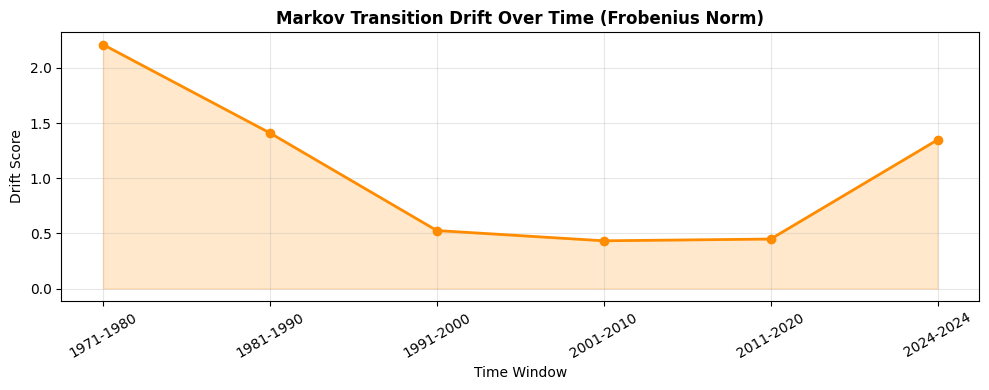


Dynamic model ready. Sectors: 28


In [12]:
dynamic = DynamicMarkovModel(
    transitions_df = train_data,
    time_col       = 'year',
    current_col    = 'esco_sector',
    next_col       = 'next_sector'
)

dynamic.create_time_intervals(window_size=10)
dynamic.build_matrices(smoothing=0.05)
dynamic.compute_drift()
dynamic.plot_drift_over_time()

print(f"\nDynamic model ready. Sectors: {len(dynamic.job_index)}")


# Evaluate Model (with Statistical Validation)

In [13]:
import numpy as np
import pandas as pd

class MarkovPredictor:
    def __init__(self, static_model, dynamic_model):
        self.static = static_model
        self.dynamic = dynamic_model

    def evaluate_persistence(self, test_df, current_col='esco_sector', next_col='next_sector'):
        correct = (test_df[current_col] == test_df[next_col]).sum()
        accuracy = correct / len(test_df) if len(test_df) > 0 else 0
        print(f"Persistence Baseline  Top-1: {accuracy:.2%}")
        return accuracy

    def evaluate_static(self, test_df, current_col='esco_sector', next_col='next_sector', top_k_list=[1, 3, 5]):
        correct = {k: 0 for k in top_k_list}
        total = 0
        for _, row in test_df.iterrows():
            curr, actual = row[current_col], row[next_col]
            if curr not in self.static.sector_map:
                continue
            total += 1
            preds = self.static.next_sector(curr, top_k=max(top_k_list))
            pred_jobs = [p[0] for p in preds]
            for k in top_k_list:
                if actual in pred_jobs[:k]:
                    correct[k] += 1
        accuracies = {f'top_{k}': correct[k]/total if total > 0 else 0 for k in top_k_list}
        print(f"\nStatic Model")
        for k, acc in accuracies.items():
            print(f"  {k.upper()}: {acc:.2%}")
        return accuracies

    def evaluate_dynamic(self, test_df, current_col='esco_sector', next_col='next_sector',
                          time_col='year', top_k_list=[1, 3, 5]):
        correct = {k: 0 for k in top_k_list}
        total = 0
        all_jobs = list(self.dynamic.job_index.keys())
        for _, row in test_df.iterrows():
            curr, actual, yr = row[current_col], row[next_col], row[time_col]
            if curr not in self.dynamic.job_index:
                continue
            total += 1
            c_idx = self.dynamic.job_index[curr]
            probs = self.dynamic.global_matrix[c_idx]
            for (s, e), mat in self.dynamic.transition_matrices.items():
                if s <= yr <= e:
                    probs = mat[c_idx]
                    break
            top_indices = np.argsort(probs)[::-1][:max(top_k_list)]
            pred_jobs = [all_jobs[i] for i in top_indices]
            for k in top_k_list:
                if actual in pred_jobs[:k]:
                    correct[k] += 1
        accuracies = {f'top_{k}': correct[k]/total if total > 0 else 0 for k in top_k_list}
        print(f"\nDynamic Model")
        for k, acc in accuracies.items():
            print(f"  {k.upper()}: {acc:.2%}")
        return accuracies


## Statistical Validation: Multi-Seed Confidence Intervals

To ensure results are not seed-dependent, we evaluate across 5 random seeds and report **mean ± 95% CI** for each model. This is standard practice for research submissions and distinguishes genuine model improvement from lucky splits.

In [14]:
from scipy import stats as scipy_stats

def run_multi_seed_validation(transitions_df, n_seeds=5, test_size=0.2):
    """
    Runs model evaluation across multiple random seeds.
    Reports mean ± 95% CI for each model and top-k metric.
    """
    seeds = [42, 7, 13, 99, 2024]
    results = {'persistence': [], 'static_top1': [], 'dynamic_top1': [],
               'static_top3': [], 'dynamic_top3': [],
               'static_top5': [], 'dynamic_top5': []}

    all_users = transitions_df['person_id'].unique()

    for seed_i, seed in enumerate(seeds[:n_seeds]):
        print(f"\n{'='*50}")
        print(f" Seed {seed} ({seed_i+1}/{n_seeds})")
        print(f"{'='*50}")
        rng = np.random.default_rng(seed)
        shuffled = rng.permutation(all_users)
        split_idx = int(len(shuffled) * (1 - test_size))
        tr_users = shuffled[:split_idx]
        te_users = shuffled[split_idx:]
        tr_data = transitions_df[transitions_df['person_id'].isin(tr_users)].copy()
        te_data = transitions_df[transitions_df['person_id'].isin(te_users)].copy()

        s_model = CareerTransitionModel(career_data=tr_data, smoothing=0.05)
        s_model.transition_patterns()

        d_model = DynamicMarkovModel(transitions_df=tr_data)
        d_model.create_time_intervals(window_size=10)
        d_model.build_matrices(smoothing=0.05)

        pred = MarkovPredictor(s_model, d_model)

        p_acc = pred.evaluate_persistence(te_data)
        s_acc = pred.evaluate_static(te_data, top_k_list=[1, 3, 5])
        d_acc = pred.evaluate_dynamic(te_data, top_k_list=[1, 3, 5])

        results['persistence'].append(p_acc)
        for k in [1, 3, 5]:
            results[f'static_top{k}'].append(s_acc[f'top_{k}'])
            results[f'dynamic_top{k}'].append(d_acc[f'top_{k}'])

    print(f"\n{'='*65}")
    print(f" STATISTICAL VALIDATION RESULTS ({n_seeds} seeds)")
    print(f"{'='*65}")
    print(f"{'Metric':<30} {'Mean':>8} {'Std':>8} {'95% CI':>20}")
    print("-" * 65)

    summary = {}
    for key, vals in results.items():
        vals = np.array(vals)
        mean = vals.mean()
        std = vals.std(ddof=1)
        if len(vals) > 1:
            ci = scipy_stats.t.interval(0.95, df=len(vals)-1, loc=mean, scale=scipy_stats.sem(vals))
        else:
            ci = (mean, mean)
        summary[key] = {'mean': mean, 'std': std, 'ci': ci}
        print(f"  {key:<28} {mean:>7.2%} {std:>7.2%}  [{ci[0]:.2%}, {ci[1]:.2%}]")

    print(f"\n{'─'*65}")
    print(" Paired t-test: Dynamic vs Static (Top-1)")
    static_scores  = np.array(results['static_top1'])
    dynamic_scores = np.array(results['dynamic_top1'])
    if len(static_scores) > 1:
        t_stat, p_val = scipy_stats.ttest_rel(dynamic_scores, static_scores)
        sig = '*** (p<0.05 SIGNIFICANT)' if p_val < 0.05 else '(NOT significant — temporal windowing does not improve over global counts on this dataset)'
        print(f"  t-statistic: {t_stat:.3f}  |  p-value: {p_val:.4f}  {sig}")

    return summary

validation_summary = run_multi_seed_validation(transitions, n_seeds=5)



 Seed 42 (1/5)
Unique Sectors : 28
Actual Zero Paths:     40
Sparsity: 5.10%
----------------------------------------
Years           | Sparsity   | Status
----------------------------------------
1958-1970    |    95.79% | Built
1971-1980    |    60.20% | Built
1981-1990    |    29.21% | Built
1991-2000    |    15.05% | Built
2001-2010    |     8.04% | Built
2011-2020    |     9.82% | Built
2024-2024    |    66.96% | Built
Persistence Baseline  Top-1: 26.22%

Static Model
  TOP_1: 43.08%
  TOP_3: 75.47%
  TOP_5: 83.28%

Dynamic Model
  TOP_1: 43.69%
  TOP_3: 75.68%
  TOP_5: 83.38%

 Seed 7 (2/5)
Unique Sectors : 28
Actual Zero Paths:     42
Sparsity: 5.36%
----------------------------------------
Years           | Sparsity   | Status
----------------------------------------
1958-1970    |    95.41% | Built
1971-1980    |    59.95% | Built
1981-1990    |    28.83% | Built
1991-2000    |    15.56% | Built
2001-2010    |     8.16% | Built
2011-2020    |    10.20% | Built
2024-2024    | 

## Model Evaluation

| Model | Description |
|-------|-------------|
| **Persistence Baseline** | Predicts same sector (no change) — lower bound |
| **Static Markov** | Global transition matrix with Laplace smoothing |
| **Dynamic Markov** | Decade-windowed matrices capturing temporal drift |

All models evaluated on 20% held-out users across 5 random seeds. Metrics: Top-1 / Top-3 / Top-5 accuracy.
Statistical significance tested via paired t-test (Dynamic vs Static).


# Calculate Accuracy (Full Evaluation)

In [15]:
predictor = MarkovPredictor(static, dynamic)

persistence_acc = predictor.evaluate_persistence(test_data)
static_results  = predictor.evaluate_static(test_data, top_k_list=[1, 3, 5])
dynamic_results = predictor.evaluate_dynamic(test_data, top_k_list=[1, 3, 5])

print(f"\n{'='*55}")
print(f" SUMMARY (seed=42 split)")
print(f"{'='*55}")
print(f"  Persistence Baseline (Top-1):   {persistence_acc:.2%}")
print(f"  Static  Model  (Top-1):         {static_results['top_1']:.2%}")
print(f"  Dynamic Model  (Top-1):         {dynamic_results['top_1']:.2%}")
print(f"\n  Static  vs Baseline:  {static_results['top_1'] - persistence_acc:+.2%}")
print(f"  Dynamic vs Baseline:  {dynamic_results['top_1'] - persistence_acc:+.2%}")
print(f"  Dynamic vs Static:    {dynamic_results['top_1'] - static_results['top_1']:+.2%}")


Persistence Baseline  Top-1: 26.11%

Static Model
  TOP_1: 42.93%
  TOP_3: 75.29%
  TOP_5: 83.24%

Dynamic Model
  TOP_1: 43.47%
  TOP_3: 75.55%
  TOP_5: 83.41%

 SUMMARY (seed=42 split)
  Persistence Baseline (Top-1):   26.11%
  Static  Model  (Top-1):         42.93%
  Dynamic Model  (Top-1):         43.47%

  Static  vs Baseline:  +16.82%
  Dynamic vs Baseline:  +17.36%
  Dynamic vs Static:    +0.55%


# Error Analysis: Where Does Dynamic Help?

In [16]:
def error_analysis(test_df, static_model, dynamic_model,
                   current_col='esco_sector', next_col='next_sector', time_col='year'):
    """
    Analyses where Dynamic outperforms Static:
    - By sector (rare vs common)
    - Career shifts (cross-sector transitions)
    - Long-term users (many transitions)
    """
    all_jobs = list(dynamic_model.job_index.keys())

    rows = []
    for _, row in test_df.iterrows():
        curr, actual, yr = row[current_col], row[next_col], row[time_col]
        if curr not in static_model.sector_map or curr not in dynamic_model.job_index:
            continue

        # Static prediction
        s_preds = [p[0] for p in static_model.next_sector(curr, top_k=1)]
        static_correct = int(actual == s_preds[0]) if s_preds else 0

        # Dynamic prediction
        c_idx = dynamic_model.job_index[curr]
        probs = dynamic_model.global_matrix[c_idx]
        for (s, e), mat in dynamic_model.transition_matrices.items():
            if s <= yr <= e:
                probs = mat[c_idx]
                break
        top_idx = np.argsort(probs)[::-1][0]
        d_pred = all_jobs[top_idx] if top_idx < len(all_jobs) else ''
        dynamic_correct = int(actual == d_pred)

        rows.append({
            'current': curr,
            'actual': actual,
            'year': yr,
            'is_career_shift': int(curr != actual),
            'static_correct': static_correct,
            'dynamic_correct': dynamic_correct,
            'dynamic_wins': int(dynamic_correct and not static_correct),
            'static_wins': int(static_correct and not dynamic_correct),
        })

    ea = pd.DataFrame(rows)

    print("\n" + "="*60)
    print(" ERROR ANALYSIS: Where Does Dynamic Beat Static?")
    print("="*60)

    # 1. Career shifts
    for is_shift, label in [(0, 'Same-sector (stay)'), (1, 'Cross-sector (shift)')]:
        sub = ea[ea['is_career_shift'] == is_shift]
        if len(sub) == 0:
            continue
        s_acc = sub['static_correct'].mean()
        d_acc = sub['dynamic_correct'].mean()
        delta = d_acc - s_acc
        n = len(sub)
        print(f"\n  {label} (n={n:,})")
        print(f"    Static accuracy:  {s_acc:.2%}")
        print(f"    Dynamic accuracy: {d_acc:.2%}  (delta: {delta:+.2%})")

    # 2. By sector (dynamic advantage per sector)
    print("\n" + "-"*60)
    print("  Dynamic vs Static advantage BY SECTOR (Top-1)")
    sector_stats = (
        ea.groupby('current')
        .agg(n=('static_correct','count'),
             static_acc=('static_correct','mean'),
             dynamic_acc=('dynamic_correct','mean'))
        .assign(delta=lambda x: x['dynamic_acc'] - x['static_acc'])
        .sort_values('delta', ascending=False)
    )
    print(f"\n  {'Sector':<45} {'n':>6} {'Static':>8} {'Dynamic':>8} {'Delta':>8}")
    print("  " + "-" * 78)
    for sec, row_ in sector_stats.iterrows():
        flag = " <-- Dynamic wins" if row_['delta'] > 0.01 else (" <-- Static wins" if row_['delta'] < -0.01 else "")
        print(f"  {sec:<45} {row_['n']:>6,} {row_['static_acc']:>7.1%} {row_['dynamic_acc']:>8.1%} {row_['delta']:>+7.1%}{flag}")

    # 3. Temporal analysis: does dynamic improve in later years?
    print("\n" + "-"*60)
    print("  Accuracy by decade")
    ea['decade'] = (ea['year'] // 10) * 10
    dec_stats = (
        ea.groupby('decade')
        .agg(n=('static_correct','count'),
             static_acc=('static_correct','mean'),
             dynamic_acc=('dynamic_correct','mean'))
        .assign(delta=lambda x: x['dynamic_acc'] - x['static_acc'])
    )
    print(f"\n  {'Decade':<10} {'n':>6} {'Static':>8} {'Dynamic':>8} {'Delta':>8}")
    print("  " + "-" * 45)
    for dec, row_ in dec_stats.iterrows():
        print(f"  {dec}s{'':<7} {row_['n']:>6,} {row_['static_acc']:>7.1%} {row_['dynamic_acc']:>8.1%} {row_['delta']:>+7.1%}")

    return ea, sector_stats


ea_df, sector_stats = error_analysis(test_data, static, dynamic)


 ERROR ANALYSIS: Where Does Dynamic Beat Static?

  Same-sector (stay) (n=21,973)
    Static accuracy:  28.45%
    Dynamic accuracy: 24.39%  (delta: -4.06%)

  Cross-sector (shift) (n=62,177)
    Static accuracy:  48.05%
    Dynamic accuracy: 50.22%  (delta: +2.17%)

------------------------------------------------------------
  Dynamic vs Static advantage BY SECTOR (Top-1)

  Sector                                             n   Static  Dynamic    Delta
  ------------------------------------------------------------------------------
  Healthcare - Clinical                         3,172.0   32.3%    36.9%   +4.5% <-- Dynamic wins
  Education - Teaching                          6,470.0   45.5%    47.7%   +2.2% <-- Dynamic wins
  Healthcare - Nursing & Allied                 6,142.0   37.2%    39.0%   +1.8% <-- Dynamic wins
  Human Resources & Recruitment                 1,192.0   29.4%    30.8%   +1.4% <-- Dynamic wins
  Sales & Business Development                  4,131.0   34.2%   

# Visualize Drift Risk

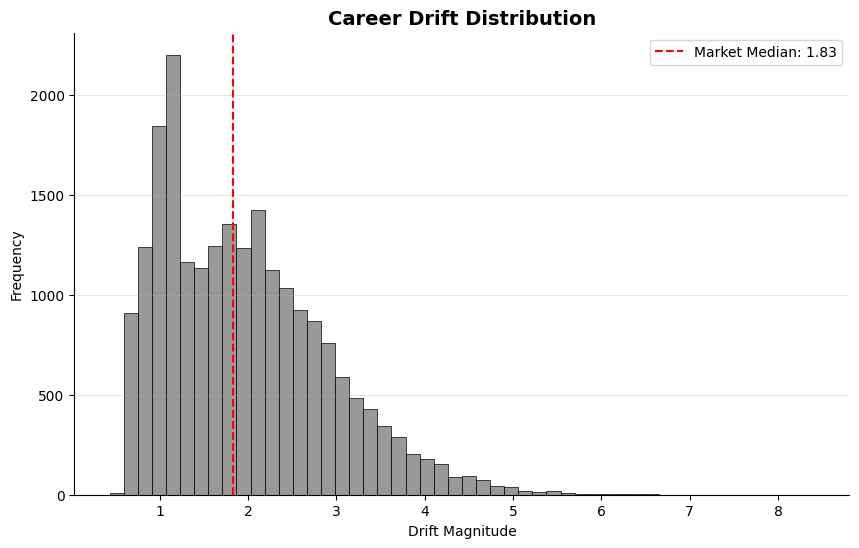

In [17]:
scorer = CareerDriftRisk(
    career_model = dynamic,
    user_col     = 'person_id',
    current_col  = 'esco_sector',
    next_col     = 'next_sector',
    time_col     = 'year'
)

risk_df = scorer.next_path(test_data, min_history=2)
scorer.plot_drift(risk_df)

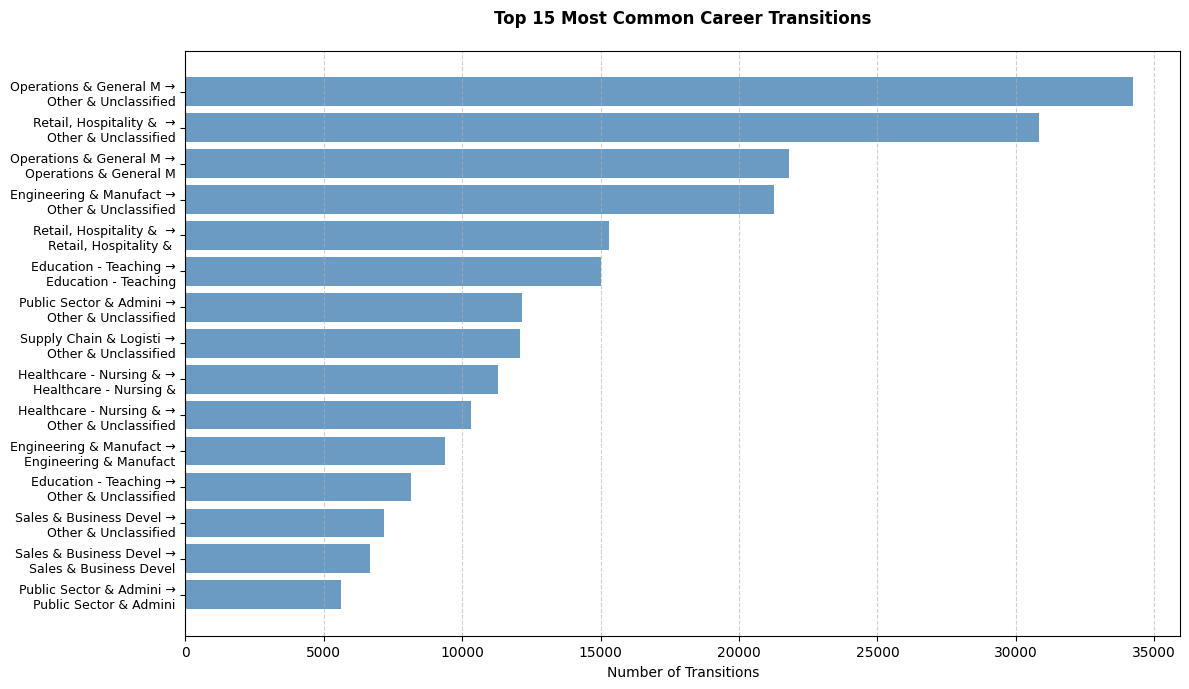

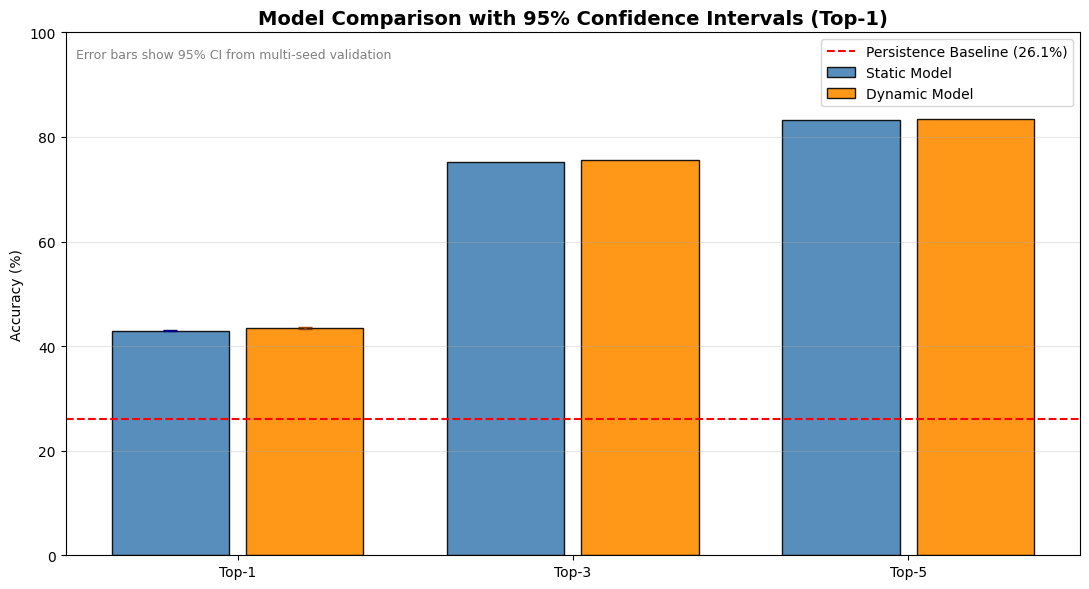

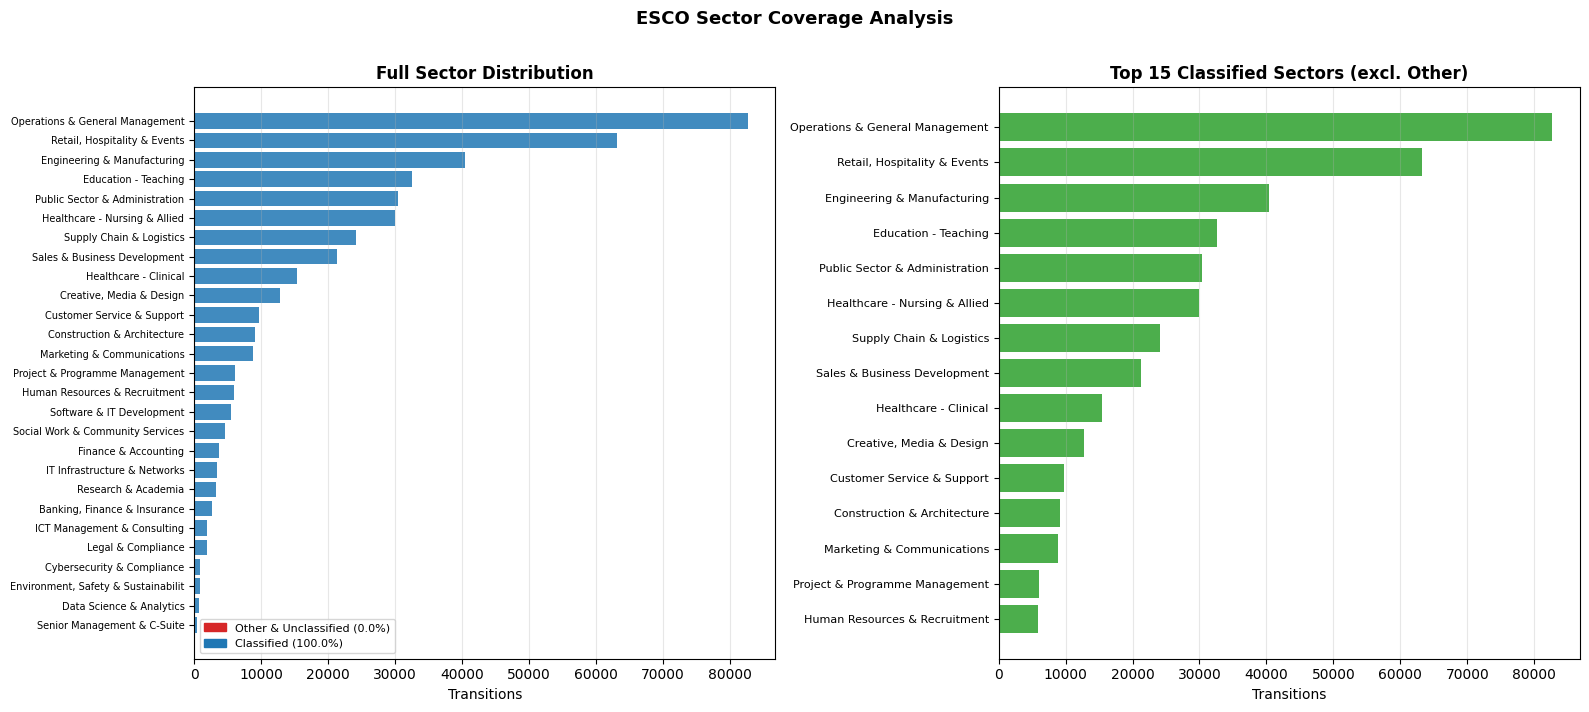


Classified: 100.0% | Other & Unclassified: 0.0%


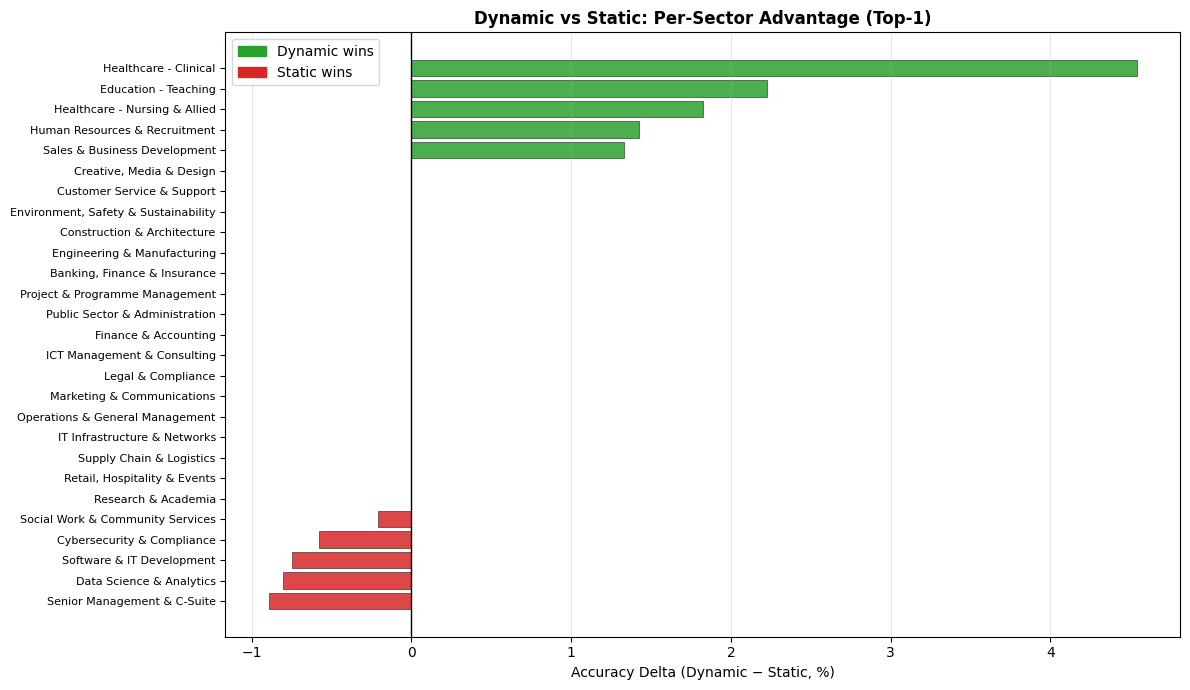


TOP 10 HIGHEST DRIFT RISK USERS (OUTLIERS)
 person_id  drift_score  total_transitions
    258035     8.409175                  2
     66481     7.379615                  5
    262370     6.913304                  2
    442514     6.669666                  2
    181723     6.529074                  2
    119063     6.505093                  3
     20718     6.481067                  2
    439228     6.365268                  2
     69223     6.282400                  2
    358338     6.211618                  2


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ── Plot 1: Top 15 Transitions ──────────────────────────────────────────────
top_transitions = (
    transitions
    .groupby(['esco_sector', 'next_sector'])
    .size()
    .reset_index(name='count')
    .sort_values('count', ascending=False)
    .head(15)
)
top_transitions['pair'] = (
    top_transitions['esco_sector'].astype(str).str[:22] + ' →\n' +
    top_transitions['next_sector'].astype(str).str[:22]
)
plt.figure(figsize=(12, 7))
plt.barh(range(15), top_transitions['count'], color='steelblue', alpha=0.8)
plt.yticks(range(15), top_transitions['pair'], fontsize=9)
plt.gca().invert_yaxis()
plt.xlabel('Number of Transitions')
plt.title('Top 15 Most Common Career Transitions', fontweight='bold', pad=20)
plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# ── Plot 2: Accuracy Comparison (all models + CI from validation) ───────────
metrics_keys = ['top_1', 'top_3', 'top_5']
labels = ['Top-1', 'Top-3', 'Top-5']
s_vals = [static_results.get(m, 0)*100 for m in metrics_keys]
d_vals = [dynamic_results.get(m, 0)*100 for m in metrics_keys]
x = np.arange(len(labels))

# Extract CIs from multi-seed validation
s_ci_lo = validation_summary.get('static_top1', {}).get('ci', (static_results['top_1']*100,)*2)[0] * 100
s_ci_hi = validation_summary.get('static_top1', {}).get('ci', (static_results['top_1']*100,)*2)[1] * 100
d_ci_lo = validation_summary.get('dynamic_top1', {}).get('ci', (dynamic_results['top_1']*100,)*2)[0] * 100
d_ci_hi = validation_summary.get('dynamic_top1', {}).get('ci', (dynamic_results['top_1']*100,)*2)[1] * 100

fig, ax = plt.subplots(figsize=(11, 6))
bars_s = ax.bar(x - 0.2, s_vals, width=0.35, label='Static Model', color='steelblue', edgecolor='black', alpha=0.9)
bars_d = ax.bar(x + 0.2, d_vals, width=0.35, label='Dynamic Model', color='darkorange', edgecolor='black', alpha=0.9)
ax.axhline(y=persistence_acc*100, color='red', linestyle='--', linewidth=1.5,
            label=f'Persistence Baseline ({persistence_acc*100:.1f}%)')
# CI error bars on Top-1 only (clamp to 0 — yerr must be non-negative)
s_err_lo = max(0.0, s_vals[0] - s_ci_lo)
s_err_hi = max(0.0, s_ci_hi  - s_vals[0])
d_err_lo = max(0.0, d_vals[0] - d_ci_lo)
d_err_hi = max(0.0, d_ci_hi  - d_vals[0])
ax.errorbar(x[0]-0.2, s_vals[0], yerr=[[s_err_lo], [s_err_hi]],
             fmt='none', color='navy', capsize=5, linewidth=2)
ax.errorbar(x[0]+0.2, d_vals[0], yerr=[[d_err_lo], [d_err_hi]],
             fmt='none', color='saddlebrown', capsize=5, linewidth=2)
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('Accuracy (%)')
ax.set_ylim(0, min(100, max(d_vals)*1.25))
ax.set_title('Model Comparison with 95% Confidence Intervals (Top-1)', fontweight='bold', fontsize=14)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
ax.annotate('Error bars show 95% CI from multi-seed validation', xy=(0.01, 0.97),
             xycoords='axes fraction', fontsize=9, color='gray', va='top')
plt.tight_layout()
plt.show()

# ── Plot 3: Sector Distribution (reduced Other & Unclassified) ─────────────
sector_counts = transitions['esco_sector'].value_counts()
other_count = sector_counts.get('Other & Unclassified', 0)
classified = sector_counts.drop('Other & Unclassified', errors='ignore')
total = sector_counts.sum()

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
# Full distribution
colors = ['#d62728' if x == 'Other & Unclassified' else '#1f77b4' for x in sector_counts.index]
axes[0].barh(range(len(sector_counts)), sector_counts.values, color=colors, alpha=0.85)
axes[0].set_yticks(range(len(sector_counts)))
axes[0].set_yticklabels([s[:35] for s in sector_counts.index], fontsize=7)
axes[0].invert_yaxis()
axes[0].set_title('Full Sector Distribution', fontweight='bold')
axes[0].set_xlabel('Transitions')
axes[0].grid(axis='x', alpha=0.3)
other_patch = mpatches.Patch(color='#d62728', label=f'Other & Unclassified ({other_count/total*100:.1f}%)')
classified_patch = mpatches.Patch(color='#1f77b4', label=f'Classified ({(total-other_count)/total*100:.1f}%)')
axes[0].legend(handles=[other_patch, classified_patch], fontsize=8)

# Classified only (top 15)
top15 = classified.head(15)
axes[1].barh(range(len(top15)), top15.values, color='#2ca02c', alpha=0.85)
axes[1].set_yticks(range(len(top15)))
axes[1].set_yticklabels([s[:35] for s in top15.index], fontsize=8)
axes[1].invert_yaxis()
axes[1].set_title('Top 15 Classified Sectors (excl. Other)', fontweight='bold')
axes[1].set_xlabel('Transitions')
axes[1].grid(axis='x', alpha=0.3)
plt.suptitle('ESCO Sector Coverage Analysis', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"\nClassified: {(total-other_count)/total*100:.1f}% | Other & Unclassified: {other_count/total*100:.1f}%")

# ── Plot 4: Error Analysis — Dynamic advantage by sector ───────────────────
if len(sector_stats) > 0:
    fig, ax = plt.subplots(figsize=(12, 7))
    colors_ea = ['#2ca02c' if d > 0 else '#d62728' for d in sector_stats['delta']]
    ax.barh(range(len(sector_stats)), sector_stats['delta']*100, color=colors_ea, alpha=0.85, edgecolor='black', linewidth=0.4)
    ax.set_yticks(range(len(sector_stats)))
    ax.set_yticklabels([s[:40] for s in sector_stats.index], fontsize=8)
    ax.invert_yaxis()
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('Accuracy Delta (Dynamic − Static, %)')
    ax.set_title('Dynamic vs Static: Per-Sector Advantage (Top-1)', fontweight='bold')
    green_patch = mpatches.Patch(color='#2ca02c', label='Dynamic wins')
    red_patch = mpatches.Patch(color='#d62728', label='Static wins')
    ax.legend(handles=[green_patch, red_patch])
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

print('\nTOP 10 HIGHEST DRIFT RISK USERS (OUTLIERS)')
print(risk_df.nlargest(10, 'drift_score').to_string(index=False))

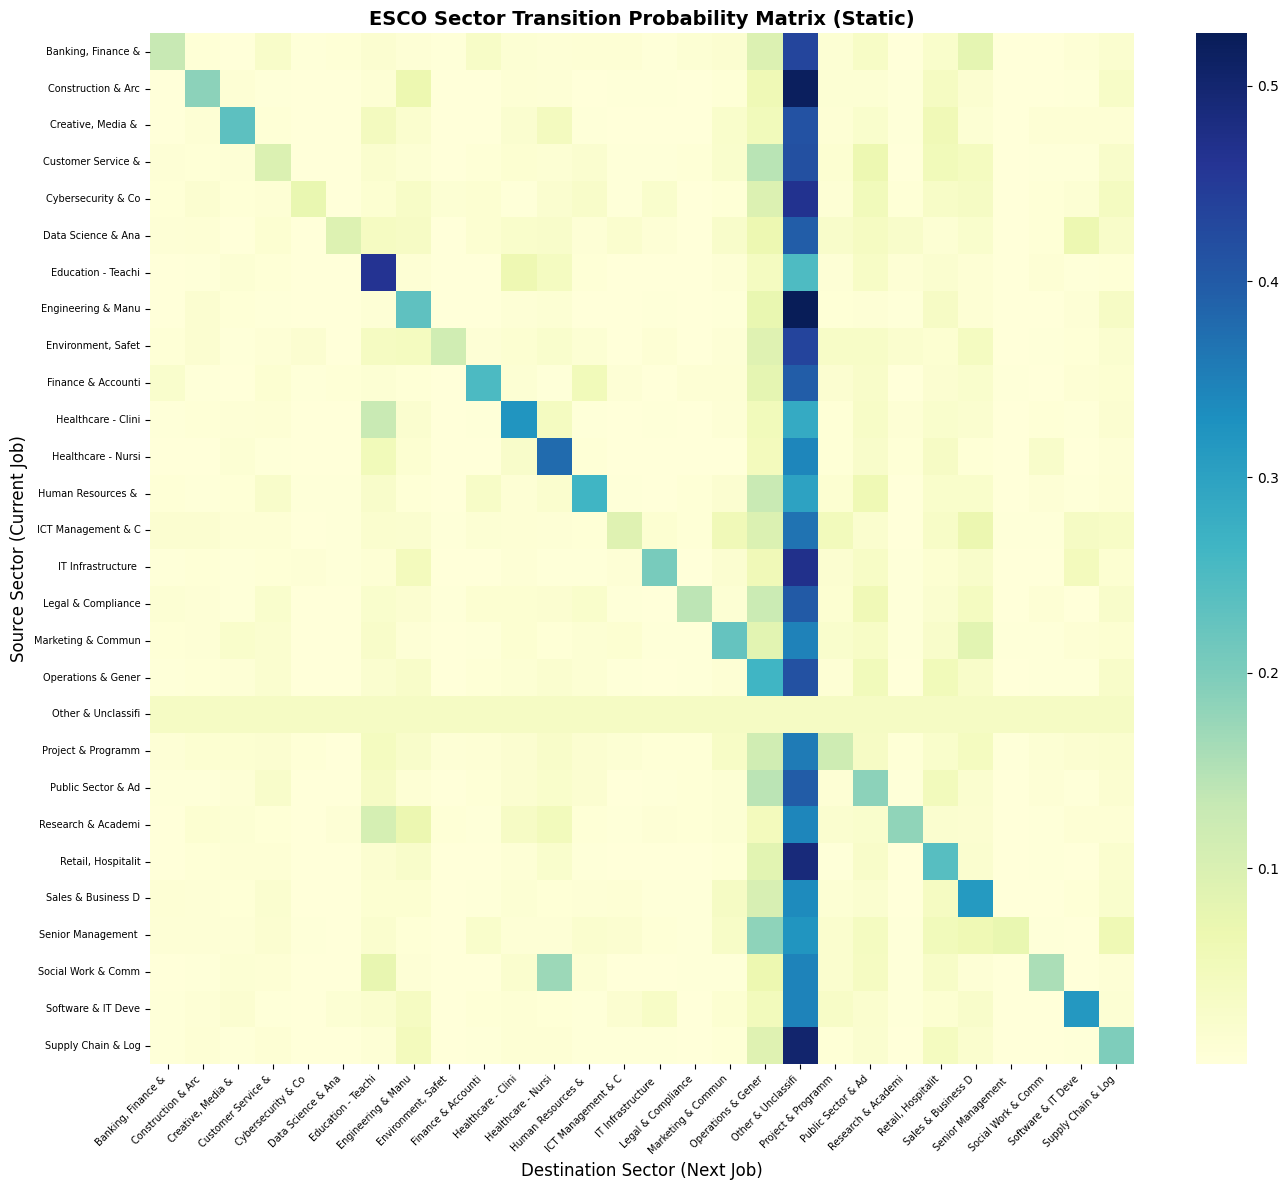

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 12))
sector_names = list(static.sector_map.keys())
annot = len(sector_names) <= 20  # only annotate if not too many sectors
sns.heatmap(static.probabilities,
            annot=annot,
            fmt='.1%' if annot else '',
            cmap='YlGnBu',
            xticklabels=[s[:18] for s in sector_names],
            yticklabels=[s[:18] for s in sector_names])
plt.title('ESCO Sector Transition Probability Matrix (Static)', fontsize=14, fontweight='bold')
plt.xlabel('Destination Sector (Next Job)', fontsize=12)
plt.ylabel('Source Sector (Current Job)', fontsize=12)
plt.xticks(fontsize=7, rotation=45, ha='right')
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()